# ネットワーク力学の基礎：3頂点の線形モデル

対応章：[42_love_dynamics_network.md](../chapters/42_love_dynamics_network.md)

固定した隣接行列と時間変化する頂点状態を区別し，固有値，初期微分，厳密解を用いて実装を検証する．循環の臨界値だけでなく，鎖には有限の臨界値がない例も扱う．

## ライブラリと隣接行列

`A[i, j]` は頂点 `j` から `i` への係数を表す．Pythonの頂点0，1，2が図のnode 1，2，3である．

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import expm

import networkx as nx

labels = ['node 1', 'node 2', 'node 3']
A = np.array([[0.0, 0.8, 0.0], [0.0, 0.0, 1.0], [0.5, 0.0, 0.0]])
print(A)

[[0.  0.8 0. ]
 [0.  0.  1. ]
 [0.5 0.  0. ]]


## 数値解と参照解の関数

41と同じ行列指数関数との照合を行う．このNotebookでは自己減衰を正，結合強度を非負に限定する．負の辺を含む行列も計算できるが，スペクトル半径を最大実部の代わりには使わない．

In [2]:
def square_matrix(matrix):
    raw = np.asarray(matrix)
    if np.iscomplexobj(raw):
        raise ValueError('This notebook uses real matrices.')
    matrix = np.asarray(raw, dtype=float)
    if (matrix.ndim != 2 or matrix.shape[0] != matrix.shape[1]
            or matrix.shape[0] == 0 or not np.all(np.isfinite(matrix))):
        raise ValueError('matrix must be a nonempty finite square matrix')
    return matrix


def linear_inputs(matrix, x0, times):
    matrix = square_matrix(matrix)
    if np.iscomplexobj(x0) or np.iscomplexobj(times):
        raise ValueError('states and times must be real')
    x0, times = np.asarray(x0, dtype=float), np.asarray(times, dtype=float)
    if x0.shape != (matrix.shape[0],) or not np.all(np.isfinite(x0)):
        raise ValueError('x0 must match the matrix dimension and be finite')
    if (times.ndim != 1 or len(times) < 2 or not np.all(np.isfinite(times))
            or np.any(np.diff(times) <= 0)):
        raise ValueError('times must contain at least two increasing finite values')
    return matrix, x0, times


def solve_linear(matrix, x0, times, rtol=1e-8, atol=1e-10):
    matrix, x0, times = linear_inputs(matrix, x0, times)
    if not (np.isfinite(rtol) and np.isfinite(atol) and rtol > 0 and atol > 0):
        raise ValueError('rtol and atol must be finite and positive')
    sol = solve_ivp(lambda t, x: matrix @ x, (times[0], times[-1]), x0,
                    t_eval=times, rtol=rtol, atol=atol)
    if not sol.success:
        raise RuntimeError(sol.message)
    if sol.y.shape != (len(x0), len(times)) or not np.all(np.isfinite(sol.y)):
        raise RuntimeError('incomplete or nonfinite solution')
    return sol


def linear_reference(matrix, x0, times):
    matrix, x0, times = linear_inputs(matrix, x0, times)
    result = np.column_stack([expm(matrix * (t - times[0])) @ x0 for t in times])
    if not np.all(np.isfinite(result)):
        raise RuntimeError('nonfinite matrix-exponential reference')
    return result

In [3]:
def network_matrix(A, alpha, beta):
    A = square_matrix(A)
    if not np.isfinite(alpha) or alpha <= 0:
        raise ValueError('alpha must be finite and positive')
    if not np.isfinite(beta) or beta < 0:
        raise ValueError('beta must be finite and nonnegative')
    return -alpha*np.eye(len(A)) + beta*A


def spectral_abscissa(M):
    return float(np.linalg.eigvals(square_matrix(M)).real.max())

## 行列と有向グラフを照合する

各要素について `j -> i` の辺を追加する．NetworkXの標準の行列変換は送り手を行に取るので，元へ戻すときは転置する．固有値は転置しても変わらず，方向確認には使えない．図の頂点位置は物理的距離を意味しない．

[NetworkX：from_numpy_array](https://networkx.org/documentation/stable/reference/generated/networkx.convert_matrix.from_numpy_array.html)

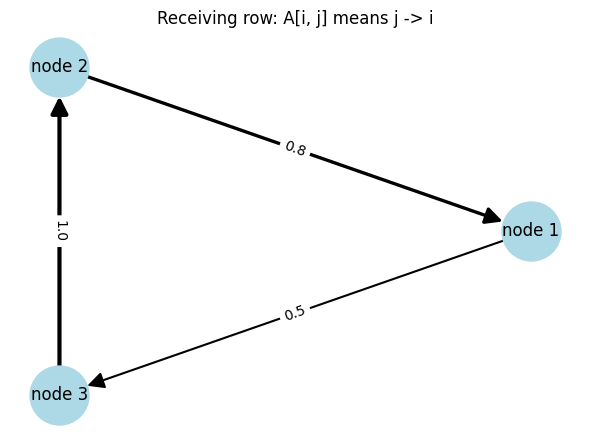

In [4]:
G = nx.DiGraph()
G.add_nodes_from(range(3))
for i in range(3):
    for j in range(3):
        if A[i, j] != 0:
            G.add_edge(j, i, weight=float(A[i, j]))
np.testing.assert_allclose(nx.to_numpy_array(G, nodelist=range(3)).T, A)
assert set(G.edges()) == {(1, 0), (0, 2), (2, 1)}
fig, ax = plt.subplots(figsize=(6, 4.5))
pos = nx.circular_layout(G)
widths = [3 * abs(G[u][v]['weight']) for u, v in G.edges()]
nx.draw_networkx(G, pos, ax=ax, labels=dict(enumerate(labels)), node_color='lightblue',
                 node_size=1800, arrows=True, arrowsize=25, width=widths)
nx.draw_networkx_edge_labels(G, pos, ax=ax,
    edge_labels={(u, v): f"{G[u][v]['weight']:.1f}" for u, v in G.edges()})
ax.set_title('Receiving row: A[i, j] means j -> i')
ax.set_axis_off(); fig.tight_layout(); plt.show()

## 固有値と理論的な臨界値

$A^3=0.4I$ なので正の実固有値は $r=\sqrt[3]{0.4}$ である．$\beta\ge0$ で最大実部は $-\alpha+\beta r$，臨界値は $\alpha/r$ となる．基準値 $\alpha=0.8,\beta=0.6$ は安定側である．境界上ではゼロ固有値の成分が残り，一般には原点へ収束しない．

In [5]:
alpha, beta = 0.8, 0.6
M = network_matrix(A, alpha, beta)
eigenvalues = np.linalg.eigvals(M)
r = np.cbrt(0.4)
beta_c = alpha/r
np.testing.assert_allclose(np.linalg.matrix_power(A, 3), 0.4*np.eye(3))
np.testing.assert_allclose(spectral_abscissa(M), -alpha+beta*r)
print('M =', M, sep='\n')
print('eigenvalues =', eigenvalues)
print('largest real part =', spectral_abscissa(M))
print('critical beta =', beta_c)

M =
[[-0.8   0.48  0.  ]
 [ 0.   -0.8   0.6 ]
 [ 0.3   0.   -0.8 ]]
eigenvalues = [-1.02104189+0.38285578j -1.02104189-0.38285578j -0.35791622+0.j        ]
largest real part = -0.35791622016315366
critical beta = 1.0857670466379628


## 初期微分と短時間の応答

初期状態はnode 1だけを1にする．$M\mathbf e_1=(-\alpha,0,0.5\beta)^\top$ であり，node 3は1次，node 2は2次の項から応答する．左図は全時間の数値解と参照解，右図は短時間の応答と主要項である．任意に小さな正の時刻でnode 2も非ゼロになるので，有限の伝達遅延があるわけではない．ピークの順序だけから矢印を判断しない．

initial derivative: [-0.8  0.   0.3]
max absolute error: 2.927940528918427e-10


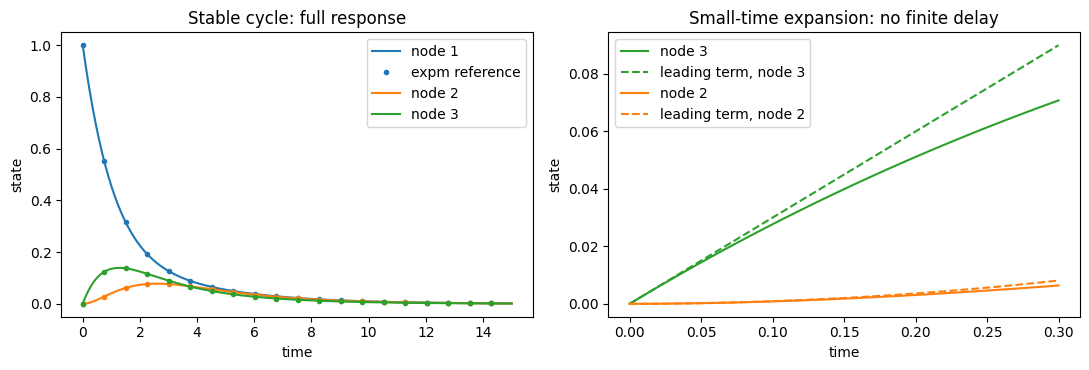

In [6]:
t_eval = np.linspace(0, 15, 400)
x0 = np.array([1.0, 0.0, 0.0])
solution = solve_linear(M, x0, t_eval)
reference = linear_reference(M, x0, t_eval)
print('initial derivative:', M @ x0)
np.testing.assert_allclose(M @ x0, [-alpha, 0.0, 0.5*beta])
print('max absolute error:', np.max(np.abs(solution.y-reference)))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for i, label in enumerate(labels):
    line, = axes[0].plot(solution.t, solution.y[i], label=label)
    axes[0].plot(t_eval[::20], reference[i, ::20], '.', color=line.get_color(),
                 label='expm reference' if i == 0 else None)
short_t = np.linspace(0, 0.3, 101)
short_x = linear_reference(M, x0, short_t)
for i, leading in [(2, 0.5*beta*short_t), (1, 0.25*beta**2*short_t**2)]:
    line, = axes[1].plot(short_t, short_x[i], color=f'C{i}', label=labels[i])
    axes[1].plot(short_t, leading, '--', color=line.get_color(), label=f'leading term, node {i+1}')
axes[0].set(xlabel='time', ylabel='state', title='Stable cycle: full response')
axes[1].set(xlabel='time', ylabel='state', title='Small-time expansion: no finite delay')
for ax in axes:
    ax.legend()
fig.tight_layout(); plt.show()

## 循環と鎖の安定性を比較する

循環の数値固有値と理論直線を重ねる．鎖は三角行列で，隣接行列の固有値がすべて0であるため，最大実部は常に $-\alpha$ となる．0より下は漸近安定，0より上は不安定である．0の近くの有限時間のグラフだけから安定性を決めない．

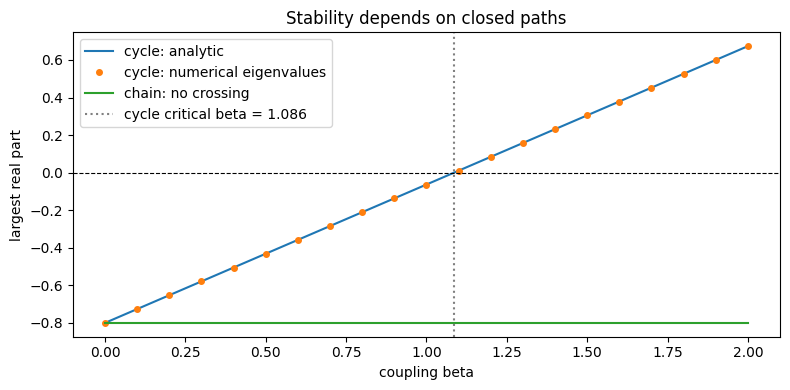

In [7]:
chain = np.array([[0.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.0, 1.0, 0.0]])
betas = np.linspace(0.0, 2.0, 161)
cycle_s = np.array([spectral_abscissa(network_matrix(A, alpha, b)) for b in betas])
chain_s = np.array([spectral_abscissa(network_matrix(chain, alpha, b)) for b in betas])
np.testing.assert_allclose(cycle_s, -alpha+betas*r, atol=1e-14)
np.testing.assert_allclose(chain_s, -alpha)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(betas, -alpha+betas*r, label='cycle: analytic')
ax.plot(betas[::8], cycle_s[::8], 'o', ms=4, label='cycle: numerical eigenvalues')
ax.plot(betas, chain_s, label='chain: no crossing')
ax.axhline(0, color='black', ls='--', lw=0.8)
ax.axvline(beta_c, color='gray', ls=':', label=f'cycle critical beta = {beta_c:.3f}')
ax.set(xlabel='coupling beta', ylabel='largest real part', title='Stability depends on closed paths')
ax.legend(); fig.tight_layout(); plt.show()

## 鎖の厳密解と一時的増幅

$A^3=0$ なので行列指数関数の級数は2次で止まる．$x(0)=\mathbf e_1$ なら $e^{-\alpha t}(1,\beta wt,(\beta wt)^2/2)^\top$ である．左図は $\beta=3,w=1$ の数値解と厳密解，右図は結合強度を変えたノルムである．すべて漸近安定でも途中の振幅は異なる．ノルムの比較は同じ状態尺度と初期ノルムで行う．

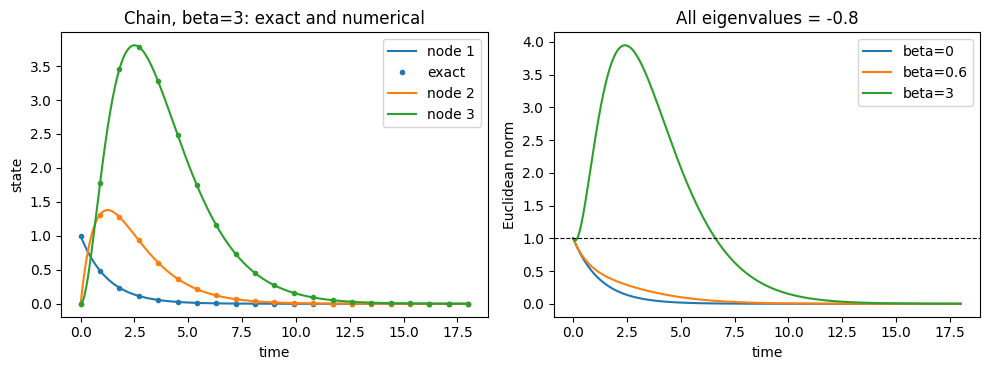

In [8]:
times = np.linspace(0, 18, 501)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for strength in [0.0, 0.6, 3.0]:
    matrix = network_matrix(chain, alpha, strength)
    sol = solve_linear(matrix, x0, times)
    exact = np.exp(-alpha*times)*np.array([
        np.ones_like(times), strength*times, (strength*times)**2/2])
    np.testing.assert_allclose(sol.y, exact, atol=5e-8, rtol=1e-7)
    axes[1].plot(times, np.linalg.norm(sol.y, axis=0), label=f'beta={strength:g}')
    if strength == 3:
        for i in range(3):
            line, = axes[0].plot(times, sol.y[i], label=labels[i])
            axes[0].plot(times[::25], exact[i, ::25], '.', color=line.get_color(),
                         label='exact' if i == 0 else None)
axes[0].set(xlabel='time', ylabel='state', title='Chain, beta=3: exact and numerical')
axes[1].set(xlabel='time', ylabel='Euclidean norm', title='All eigenvalues = -0.8')
axes[1].axhline(1, color='black', ls='--', lw=0.8)
for ax in axes:
    ax.legend()
fig.tight_layout(); plt.show()

## 課題

1. `chain_matrix(n, weight)` を作り，一方向の鎖 `node 1 -> ... -> node n` を表す隣接行列を返す．非正整数の頂点数や負の重みは拒否し，孤立した1頂点と重み0も試す．
2. `edge_table(A)` と `graph_from_A(A)` を作り，非対称な行列の非零要素と全矢印・重みを照合する．行列からグラフへ変換し，転置に注意して行列へ戻す `assert` を書く．
3. `stability_sweep(A, alpha, beta_values)` を作り，結合強度と最大固有値実部をDataFrameで返す．循環，鎖，$A=\begin{pmatrix}0&-1\\1&0\end{pmatrix}$ を比較する．臨界値が存在しない場合もそのまま報告する．
4. `chain_exact(alpha, beta, weight, times)` を作り，初期値 $(1,0,0)^\top$ の3頂点鎖の厳密解と数値解を照合する．基準の循環では $M\mathbf e_1$ を計算し，短時間の $x_3/t$ と $x_2/t^2$ の極限も確認する．
5. `network_metrics(A, alpha, beta, x0, times)` を作り，最大固有値実部，保存時刻での最大ノルム比，終了時ノルムを返す．3頂点の鎖と循環を，総辺重みがともに3となるようそろえて比較する．初期ノルムと時間窓も固定する．最大実部だけでは過渡応答を決められないことと，総重みをそろえても受け手ごとの入力は同一ではないことを考察する．

In [9]:
# 課題実装セル
# 鎖行列，辺表，グラフ変換，安定性の比較，厳密解，過渡応答の指標を実装する．